<a href="https://colab.research.google.com/github/edaviesc/Marketing-Campaign/blob/main/marketingcampaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

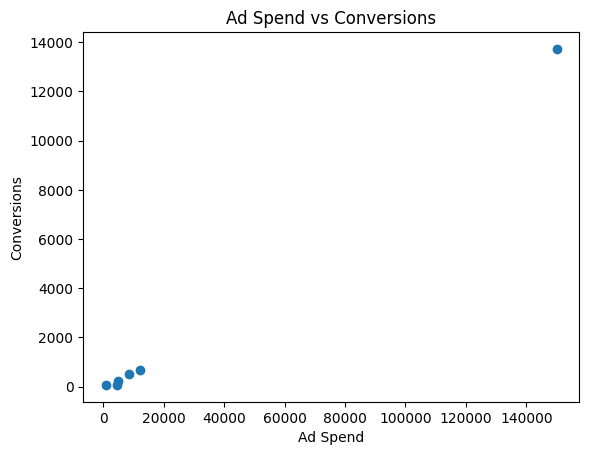

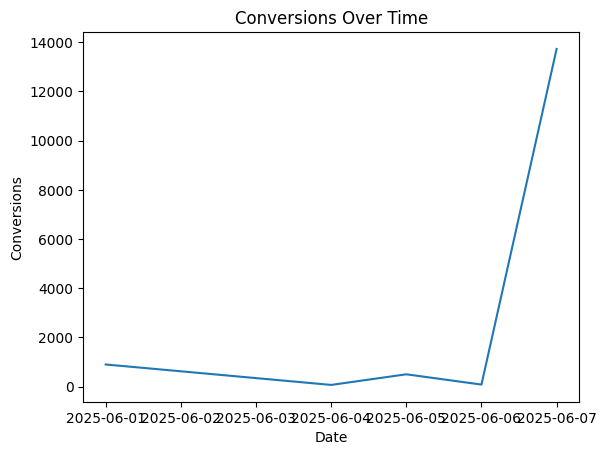

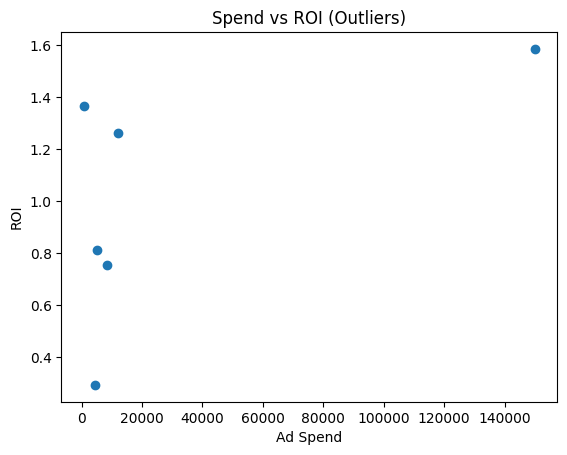

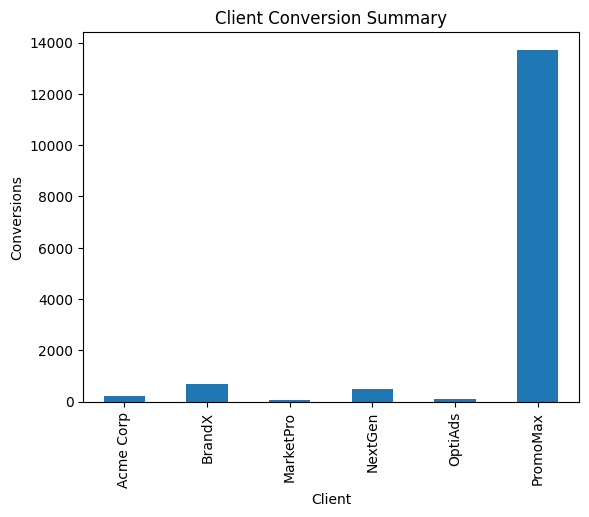

   campaign_id client_name start_date  ad_spend           client_email  \
0          201   Acme Corp 2025-06-01    5000.0       acme@example.com   
4          205   MarketPro 2025-06-04     800.0  marketpro@example.com   
5          202      BrandX 2025-06-01   12000.0     brandx@example.com   
6          206     NextGen 2025-06-05    8500.0    nextgen@example.com   
7          207     OptiAds 2025-06-06    4500.0                    NaN   

   impressions  clicks  conversions       roi  
0        53108    1247          218  0.812656  
4        11724     843           69  1.364870  
5       157487    8829          682  1.263806  
6       103620    6474          501  0.753850  
7        40914     868           83  0.292213  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# LOAD DATA
# -------------------------
file_path = "/content/drive/MyDrive/data/campaign.csv"   # adjust path if needed
df = pd.read_csv(file_path)

# -------------------------
# CLEAN DATA
# -------------------------

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert dates safely
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")

# Convert spend to numeric
df["ad_spend"] = pd.to_numeric(df["ad_spend"], errors="coerce")

# Remove duplicates
df = df.drop_duplicates()

# Fill missing spend with median
df["ad_spend"] = df["ad_spend"].fillna(df["ad_spend"].median())

# Drop rows with invalid dates
df = df.dropna(subset=["start_date"])

# -------------------------
# SIMULATE CAMPAIGN METRICS
# (since raw file lacks them)
# -------------------------

np.random.seed(42)

df["impressions"] = (
    df["ad_spend"] * np.random.uniform(8, 15, len(df))
).astype(int)

df["clicks"] = (
    df["impressions"] * np.random.uniform(0.02, 0.08, len(df))
).astype(int)

df["conversions"] = (
    df["clicks"] * np.random.uniform(0.05, 0.2, len(df))
).astype(int)

df["roi"] = (
    df["conversions"] * np.random.uniform(10, 30, len(df))
) / df["ad_spend"]

# -------------------------
# VISUALIZATION 1
# Spend vs Conversions
# -------------------------
plt.figure()
plt.scatter(df["ad_spend"], df["conversions"])
plt.title("Ad Spend vs Conversions")
plt.xlabel("Ad Spend")
plt.ylabel("Conversions")
plt.show()

# -------------------------
# VISUALIZATION 2
# Performance Over Time
# -------------------------
time_series = df.groupby("start_date")["conversions"].sum()

plt.figure()
plt.plot(time_series.index, time_series.values)
plt.title("Conversions Over Time")
plt.xlabel("Date")
plt.ylabel("Conversions")
plt.show()

# -------------------------
# VISUALIZATION 3
# Outlier Detection
# -------------------------
plt.figure()
plt.scatter(df["ad_spend"], df["roi"])
plt.title("Spend vs ROI (Outliers)")
plt.xlabel("Ad Spend")
plt.ylabel("ROI")
plt.show()

# -------------------------
# VISUALIZATION 4
# Client Summary
# -------------------------
client_summary = df.groupby("client_name")["conversions"].sum()

plt.figure()
client_summary.plot(kind="bar")
plt.title("Client Conversion Summary")
plt.xlabel("Client")
plt.ylabel("Conversions")
plt.show()

# Preview cleaned dataset
print(df.head())